Load Data - temperature and precipitation graph of data used for feature importance and predictive model returns erroneous january values compared to any meteorogical site. 

In [1]:
import pandas as pd

# Load the dataframe from CSV
df = pd.read_csv(r"..\..\data\cleaned_data_w_class.csv")

filtered_df = df[df["caffeine_class"] != "Absent"]

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation

Load Data - Validating if January data produces same anomally thoughout the raster

In [28]:
import pandas as pd

df = pd.read_csv(r"..\..\data\coll_tree_node.csv")
# df = pd.read_csv(r"..\..\data\coll_all.csv")
# df = pd.read_csv(r"..\..\data\coll_caff_node.csv")
# filtered_df = df[df['caffeine_class'] != "Absent"]

filtered_df = df.copy()


# Extract the first 36 columns

df_extracted = filtered_df.iloc[:, 8:44]  # Select the first 36 columns


# Split the dataframe into 3 separate parts

min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures

max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures

precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation



# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")

# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")


min_temps.describe()

,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),clim_3_tmin3_Monthly minimum temperature - March (°C x 10),clim_4_tmin4_Monthly minimum temperature - April (°C x 10),clim_5_tmin5_Monthly minimum temperature - May (°C x 10),clim_6_tmin6_Monthly minimum temperature - June (°C x 10),clim_7_tmin7_Monthly minimum temperature - July (°C x 10),clim_8_tmin8_Monthly minimum temperature - August (°C x 10),clim_9_tmin9_Monthly minimum temperature - September (°C x 10),clim_10_tmin10_Monthly minimum temperature - October (°C x 10),clim_11_tmin11_Monthly minimum temperature - November (°C x 10),clim_12_tmin12_Monthly minimum temperature - December (°C x 10)
count,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000
mean,178.312680,210.278098,206.280980,195.770893,172.197406,154.518732,149.951009,152.949568,162.580692,194.891931,204.548991,210.219020
std,28.101577,22.028099,23.204288,27.595474,32.206001,32.677383,31.985258,30.694210,29.500434,25.484254,23.328999,21.442521
min,103.000000,143.000000,143.000000,128.000000,104.000000,85.000000,81.000000,86.000000,89.000000,122.000000,136.000000,146.000000
25%,163.000000,197.000000,191.000000,180.000000,153.000000,135.000000,131.000000,133.000000,144.750000,179.000000,190.250000,198.000000
50%,184.500000,219.000000,216.000000,205.000000,177.000000,157.000000,154.000000,162.000000,169.000000,201.000000,213.000000,218.000000
75%,200.000000,226.000000,222.000000,216.000000,193.750000,177.000000,172.000000,173.000000,184.750000,214.000000,220.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


Renaming headers

In [ ]:
df_extracted.columns = (
    df_extracted.columns.str.replace(
        r"[^\w\s]", "", regex=True
    )  # Remove special characters like °, parentheses, hyphen
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
    .str.strip()
)  # Strip leading and trailing spaces


mapping_df = pd.read_csv(r"../../data/column_mapping.csv")

mapping_df["old_name"] = (
    mapping_df["old_name"]
    .str.replace(r"[^\w\s]", "", regex=True)  # Clean the old names similarly
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
    .str.strip()
)
mapping_df

# Create the mapping dictionary
mapping_dict = dict(zip(mapping_df["old_name"], mapping_df["new_name"]))

# Rename columns in the DataFrame using the cleaned mapping
df_extracted.rename(columns=mapping_dict, inplace=True)
df_extracted.columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,clim_11_tmin11_nov,clim_12_tmin12_dec
count,515.000000,515.000000,515.000000,515.000000,515.00000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,179.714563,212.840777,208.559223,197.733981,173.96699,156.644660,152.333981,154.899029,164.207767,196.256311,206.708738,212.722330
std,25.754719,20.086822,20.855485,25.045350,30.25284,30.848506,30.180152,28.565875,27.151068,23.188123,21.226787,19.619299
min,103.000000,143.000000,143.000000,135.000000,113.00000,90.000000,88.000000,89.000000,89.000000,122.000000,136.000000,146.000000
25%,167.000000,207.000000,200.000000,185.000000,161.00000,144.000000,140.000000,144.000000,152.000000,183.000000,200.000000,208.000000
50%,184.000000,220.000000,216.000000,205.000000,177.00000,157.000000,154.000000,162.000000,169.000000,201.000000,214.000000,219.000000
75%,200.000000,226.000000,222.000000,216.000000,194.00000,177.000000,174.000000,173.000000,182.000000,212.000000,219.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.00000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


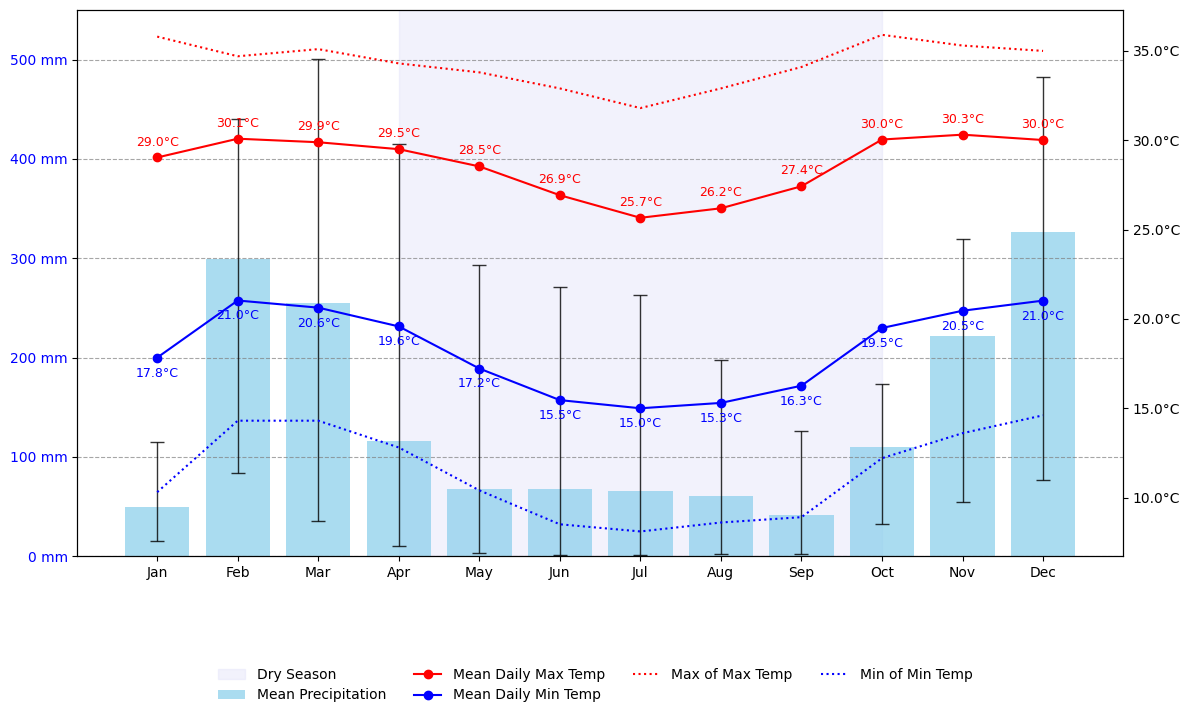

In [30]:
plot_climate_statistics(df_extracted)

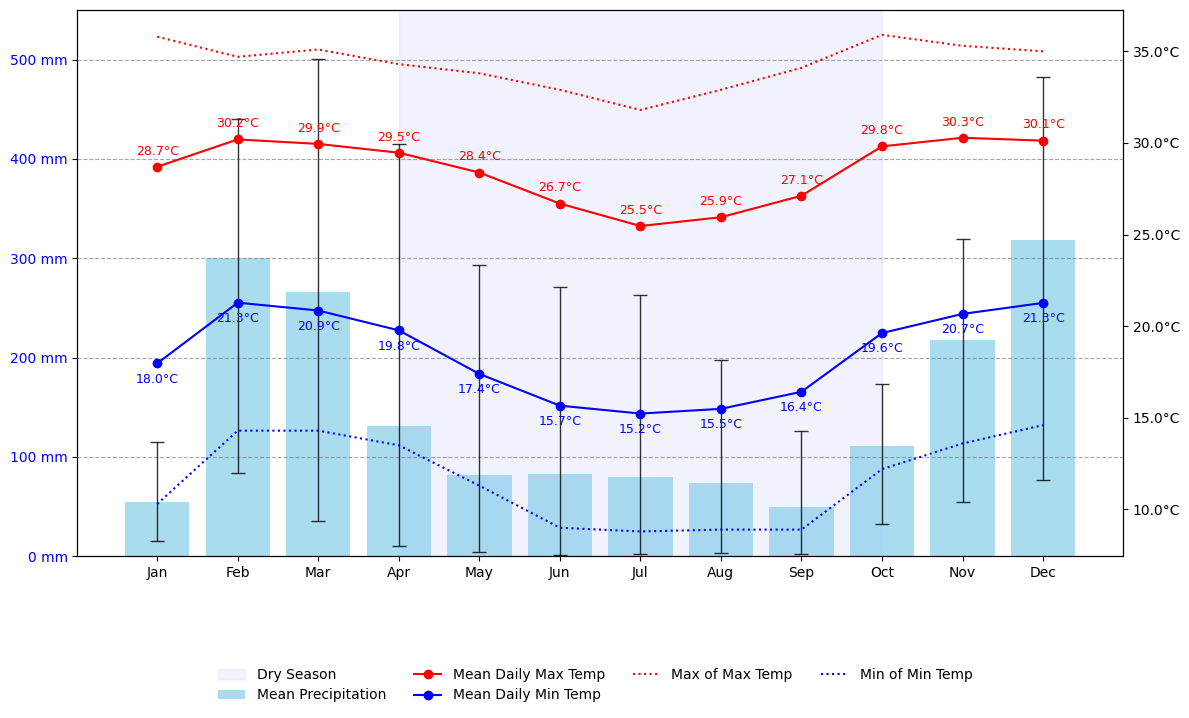

In [7]:
df = pd.read_csv(r"..\..\data\cleaned_data_num_w_class.csv")

# filtered_df = df[df['caffeine_class'] != "Absent"]
filtered_df = df.copy()

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,clim_11_tmin11_nov,clim_12_tmin12_dec
count,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,179.804183,212.990494,208.714829,197.885932,174.030418,156.652091,152.368821,155.047529,164.307985,196.355513,206.861217,212.853612
std,25.490870,19.901709,20.663343,24.803424,29.937380,30.523662,29.863258,28.283322,26.873889,22.953971,21.029180,19.433487
min,103.000000,143.000000,143.000000,135.000000,113.000000,90.000000,88.000000,89.000000,89.000000,122.000000,136.000000,146.000000
25%,167.000000,207.000000,200.500000,186.000000,161.000000,144.000000,140.000000,144.000000,153.250000,185.000000,200.000000,208.250000
50%,184.000000,220.000000,216.000000,205.000000,177.000000,157.000000,154.000000,162.000000,169.000000,201.000000,214.000000,219.000000
75%,200.000000,226.000000,222.000000,215.750000,194.000000,177.000000,174.000000,173.000000,182.000000,211.750000,219.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


In [9]:
precip.describe()

,clim_25_prec1_jan,clim_26_prec2_feb,clim_27_prec3_mar,clim_28_prec4_apr,clim_29_prec5_may,clim_30_prec6_jun,clim_31_prec7_jul,clim_32_prec8_aug,clim_33_prec9_sep,clim_34_prec10_oct,clim_35_prec11_nov,clim_36_prec12_dec
count,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,54.093156,300.395437,265.174905,130.581749,81.393536,82.302281,79.226236,72.615970,49.326996,111.060837,218.311787,318.903042
std,29.318105,87.799227,116.261101,92.811699,78.672625,79.304992,74.328154,64.366043,40.369573,41.329663,47.970921,78.698364
min,15.000000,84.000000,36.000000,10.000000,4.000000,1.000000,2.000000,3.000000,2.000000,32.000000,55.000000,77.000000
25%,26.250000,266.000000,187.000000,54.000000,16.000000,20.000000,17.000000,17.000000,12.000000,77.000000,183.000000,282.000000
50%,46.000000,300.000000,231.000000,110.000000,45.000000,39.000000,40.000000,37.000000,28.000000,107.000000,228.000000,336.000000
75%,77.000000,385.000000,393.000000,172.000000,144.000000,148.000000,141.750000,128.000000,83.000000,150.000000,254.000000,368.000000
max,115.000000,440.000000,501.000000,415.000000,293.000000,271.000000,263.000000,198.000000,126.000000,173.000000,319.000000,483.000000


In [11]:
pd.set_option("display.max_rows", 10)

min_temps

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,clim_11_tmin11_nov,clim_12_tmin12_dec
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,192.0,200.0
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,210.0,217.0
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,196.0,203.0
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,196.0,203.0
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,196.0,203.0
...,...,...,...,...,...,...,...,...,...,...,...,...
521,156.0,192.0,185.0,169.0,136.0,116.0,115.0,123.0,134.0,173.0,187.0,193.0
522,204.0,226.0,229.0,222.0,204.0,184.0,174.0,181.0,189.0,218.0,222.0,224.0
523,200.0,225.0,222.0,219.0,204.0,185.0,181.0,183.0,188.0,215.0,222.0,225.0
524,200.0,225.0,222.0,219.0,204.0,185.0,181.0,183.0,188.0,215.0,222.0,225.0


Fixing Jan data with mean of adjacent months (dec + feb)

In [10]:
df = pd.read_csv(r"..\..\data\cleaned_data_w_class.csv")

df.head()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,env_78_wat_3,env_78_wat_14,env_78_wat_13,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,caffeine_percent,caffeine_class
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,...,0,0,0,0,0,0,0,0,0.00,Absent
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,...,0,0,0,0,0,0,0,0,0.03,Low
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent


In [11]:
# Backing up the original column
df["clim_1_tmin1_jan_old"] = df["clim_1_tmin1_jan"]
df["clim_13_tmax1_jan_old"] = df["clim_13_tmax1_jan"]
df["clim_25_prec1_jan_old"] = df["clim_25_prec1_jan"]

df.head()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,caffeine_percent,caffeine_class,clim_1_tmin1_jan_old,clim_13_tmax1_jan_old,clim_25_prec1_jan_old
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,...,0,0,0,0,0,0.00,Absent,156.0,305.0,22.0
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,...,0,0,0,0,0,0.03,Low,184.0,276.0,77.0
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0


In [12]:
# Create new January columns as an average of December and February
df["clim_1_tmin1_jan"] = (df["clim_2_tmin2_feb"] + df["clim_12_tmin12_dec"]) / 2
df["clim_13_tmax1_jan"] = (df["clim_14_tmax2_feb"] + df["clim_24_tmax12_dec"]) / 2
df["clim_25_prec1_jan"] = (df["clim_26_prec2_feb"] + df["clim_36_prec12_dec"]) / 2

In [14]:
df.head()

df.to_csv(r"..\..\data\cleaned_data_w_class_new_jan.csv")

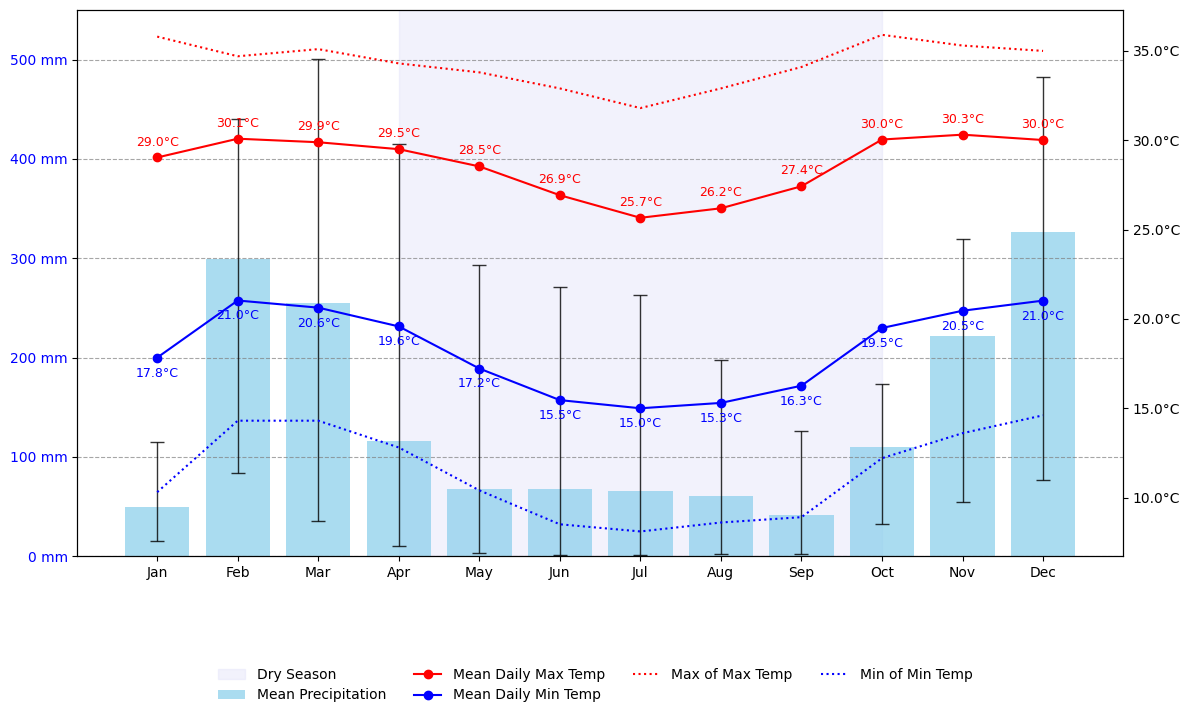

In [32]:
plot_climate_statistics(df_extracted)

In [13]:
df_extracted = df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation

Imputing jan data earlier in the pipeline 

In [33]:
df = pd.read_csv(r"..\..\data\coll_all.csv")

df.head()

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),...,clim_70_ndm_Number of dry months in the year (months.year-1),env_71_alt_Altitude (meters),env_72_slo_Slope (degrees),env_73_asp_Aspect; clockwise from North (degrees),"env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)","env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%)
0,toshii_1,4326,46.891944,-22.473333,POINT (694658.5627333813 7513551.374062283),79,0,False,155.0,191.0,...,8.0,653.0,3.0,297.0,7619.0,10.0,9.0,4.0,17.0,0.0
1,humbertii_4,4326,43.797500,-22.875000,POINT (376646.4194813568 7469814.360957881),79,0,False,156.0,198.0,...,11.0,477.0,11.0,346.0,7929.0,5.0,15.0,12.0,6.0,68.0
2,boinensis_9,4326,46.801111,-16.319444,POINT (692421.416084501 8194878.942872111),79,0,False,200.0,219.0,...,8.0,217.0,3.0,358.0,7885.0,6.0,16.0,5.0,20.0,99.0
3,bissetiae_18,4326,46.805278,-16.328889,POINT (692857.4620243979 8193829.778816624),79,0,False,200.0,219.0,...,8.0,190.0,13.0,152.0,7199.0,6.0,16.0,5.0,20.0,96.0
4,bissetiae_20,4326,46.432222,-15.588889,POINT (653558.8554503244 8276022.724140697),79,0,False,222.0,236.0,...,8.0,25.0,4.0,67.0,7814.0,1.0,16.0,5.0,9.0,29.0


In [16]:
# Backing up the original column
# df['clim_1_tmin1_jan_old'] = df['clim_1_tmin1_Monthly minimum temperature - January (°C x 10)']
# df['clim_13_tmax1_jan_old'] = df['clim_13_tmax1_Monthly maximum temperature - January (°C x 10)']
# df['clim_25_prec1_jan_old'] = df['clim_25_prec1_Monthly total precipitation - January (mm.month-1)']

# df.head()

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),...,env_73_asp_Aspect; clockwise from North (degrees),"env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)","env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)",env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%),clim_1_tmin1_jan_old,clim_13_tmax1_jan_old,clim_25_prec1_jan_old
0,toshii_1,4326,46.891944,-22.473333,POINT (694658.5627333813 7513551.374062283),79,0,False,155.0,191.0,...,297.0,7619.0,10.0,9.0,4.0,17.0,0.0,155.0,283.0,33.0
1,humbertii_4,4326,43.797500,-22.875000,POINT (376646.4194813568 7469814.360957881),79,0,False,156.0,198.0,...,346.0,7929.0,5.0,15.0,12.0,6.0,68.0,156.0,305.0,22.0
2,boinensis_9,4326,46.801111,-16.319444,POINT (692421.416084501 8194878.942872111),79,0,False,200.0,219.0,...,358.0,7885.0,6.0,16.0,5.0,20.0,99.0,200.0,348.0,27.0
3,bissetiae_18,4326,46.805278,-16.328889,POINT (692857.4620243979 8193829.778816624),79,0,False,200.0,219.0,...,152.0,7199.0,6.0,16.0,5.0,20.0,96.0,200.0,348.0,28.0
4,bissetiae_20,4326,46.432222,-15.588889,POINT (653558.8554503244 8276022.724140697),79,0,False,222.0,236.0,...,67.0,7814.0,1.0,16.0,5.0,9.0,29.0,222.0,327.0,17.0


In [20]:
# Create new January columns as an average of December and February
df["clim_1_tmin1_Monthly minimum temperature - January (°C x 10)"] = (
    df["clim_2_tmin2_Monthly minimum temperature - February (°C x 10)"]
    + df["clim_12_tmin12_Monthly minimum temperature - December (°C x 10)"]
) / 2
df["clim_13_tmax1_Monthly maximum temperature - January (°C x 10)"] = (
    df["clim_14_tmax2_Monthly maximum temperature - February (°C x 10)"]
    + df["clim_24_tmax12_Monthly maximum temperature - December (°C x 10)"]
) / 2
df["clim_25_prec1_Monthly total precipitation - January (mm.month-1)"] = (
    df["clim_26_prec2_Monthly total precipitation - February (mm.month-1)"]
    + df["clim_36_prec12_Monthly total precipitation - December (mm.month-1)"]
) / 2

In [21]:
df.to_csv(r"..\..\data\coll_all_new_jan.csv")

Same for `coll_caff_node.csv`

In [16]:
import pandas as pd

# df = pd.read_csv(r"..\..\data\coll_tree_node.csv")
# df = pd.read_csv(r"..\..\data\coll_all.csv")
df = pd.read_csv(r"..\..\data\coll_caff_node.csv")
# filtered_df = df[df['caffeine_class'] != "Absent"]
filtered_df = df.copy()

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, 8:44]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),clim_3_tmin3_Monthly minimum temperature - March (°C x 10),clim_4_tmin4_Monthly minimum temperature - April (°C x 10),clim_5_tmin5_Monthly minimum temperature - May (°C x 10),clim_6_tmin6_Monthly minimum temperature - June (°C x 10),clim_7_tmin7_Monthly minimum temperature - July (°C x 10),clim_8_tmin8_Monthly minimum temperature - August (°C x 10),clim_9_tmin9_Monthly minimum temperature - September (°C x 10),clim_10_tmin10_Monthly minimum temperature - October (°C x 10),clim_11_tmin11_Monthly minimum temperature - November (°C x 10),clim_12_tmin12_Monthly minimum temperature - December (°C x 10)
count,515.000000,515.000000,515.000000,515.000000,515.00000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,179.714563,212.840777,208.559223,197.733981,173.96699,156.644660,152.333981,154.899029,164.207767,196.256311,206.708738,212.722330
std,25.754719,20.086822,20.855485,25.045350,30.25284,30.848506,30.180152,28.565875,27.151068,23.188123,21.226787,19.619299
min,103.000000,143.000000,143.000000,135.000000,113.00000,90.000000,88.000000,89.000000,89.000000,122.000000,136.000000,146.000000
25%,167.000000,207.000000,200.000000,185.000000,161.00000,144.000000,140.000000,144.000000,152.000000,183.000000,200.000000,208.000000
50%,184.000000,220.000000,216.000000,205.000000,177.00000,157.000000,154.000000,162.000000,169.000000,201.000000,214.000000,219.000000
75%,200.000000,226.000000,222.000000,216.000000,194.00000,177.000000,174.000000,173.000000,182.000000,212.000000,219.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.00000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


In [17]:
df_extracted.columns = (
    df_extracted.columns.str.replace(
        r"[^\w\s]", "", regex=True
    )  # Remove special characters like °, parentheses, hyphen
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
    .str.strip()
)  # Strip leading and trailing spaces


mapping_df = pd.read_csv(r"../../data/column_mapping.csv")

mapping_df["old_name"] = (
    mapping_df["old_name"]
    .str.replace(r"[^\w\s]", "", regex=True)  # Clean the old names similarly
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
    .str.strip()
)
mapping_df

# Create the mapping dictionary
mapping_dict = dict(zip(mapping_df["old_name"], mapping_df["new_name"]))

# Rename columns in the DataFrame using the cleaned mapping
df_extracted.rename(columns=mapping_dict, inplace=True)
df_extracted.columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,clim_11_tmin11_nov,clim_12_tmin12_dec
count,515.000000,515.000000,515.000000,515.000000,515.00000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,179.714563,212.840777,208.559223,197.733981,173.96699,156.644660,152.333981,154.899029,164.207767,196.256311,206.708738,212.722330
std,25.754719,20.086822,20.855485,25.045350,30.25284,30.848506,30.180152,28.565875,27.151068,23.188123,21.226787,19.619299
min,103.000000,143.000000,143.000000,135.000000,113.00000,90.000000,88.000000,89.000000,89.000000,122.000000,136.000000,146.000000
25%,167.000000,207.000000,200.000000,185.000000,161.00000,144.000000,140.000000,144.000000,152.000000,183.000000,200.000000,208.000000
50%,184.000000,220.000000,216.000000,205.000000,177.00000,157.000000,154.000000,162.000000,169.000000,201.000000,214.000000,219.000000
75%,200.000000,226.000000,222.000000,216.000000,194.00000,177.000000,174.000000,173.000000,182.000000,212.000000,219.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.00000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


In [19]:
df = df_extracted.copy()
# Backing up the original column
df["clim_1_tmin1_jan_old"] = df["clim_1_tmin1_jan"]
df["clim_13_tmax1_jan_old"] = df["clim_13_tmax1_jan"]
df["clim_25_prec1_jan_old"] = df["clim_25_prec1_jan"]

df.head()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,clim_30_prec6_jun,clim_31_prec7_jul,clim_32_prec8_aug,clim_33_prec9_sep,clim_34_prec10_oct,clim_35_prec11_nov,clim_36_prec12_dec,clim_1_tmin1_jan_old,clim_13_tmax1_jan_old,clim_25_prec1_jan_old
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,...,8.0,4.0,3.0,8.0,53.0,113.0,142.0,156.0,305.0,22.0
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,...,95.0,109.0,123.0,67.0,97.0,183.0,248.0,184.0,276.0,77.0
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,30.0,17.0,14.0,18.0,80.0,143.0,150.0,161.0,317.0,30.0
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,30.0,17.0,14.0,18.0,80.0,143.0,150.0,161.0,317.0,30.0
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,30.0,17.0,14.0,18.0,80.0,143.0,150.0,161.0,317.0,30.0


In [20]:
# Create new January columns as an average of December and February
df["clim_1_tmin1_jan"] = (df["clim_2_tmin2_feb"] + df["clim_12_tmin12_dec"]) / 2
df["clim_13_tmax1_jan"] = (df["clim_14_tmax2_feb"] + df["clim_24_tmax12_dec"]) / 2
df["clim_25_prec1_jan"] = (df["clim_26_prec2_feb"] + df["clim_36_prec12_dec"]) / 2

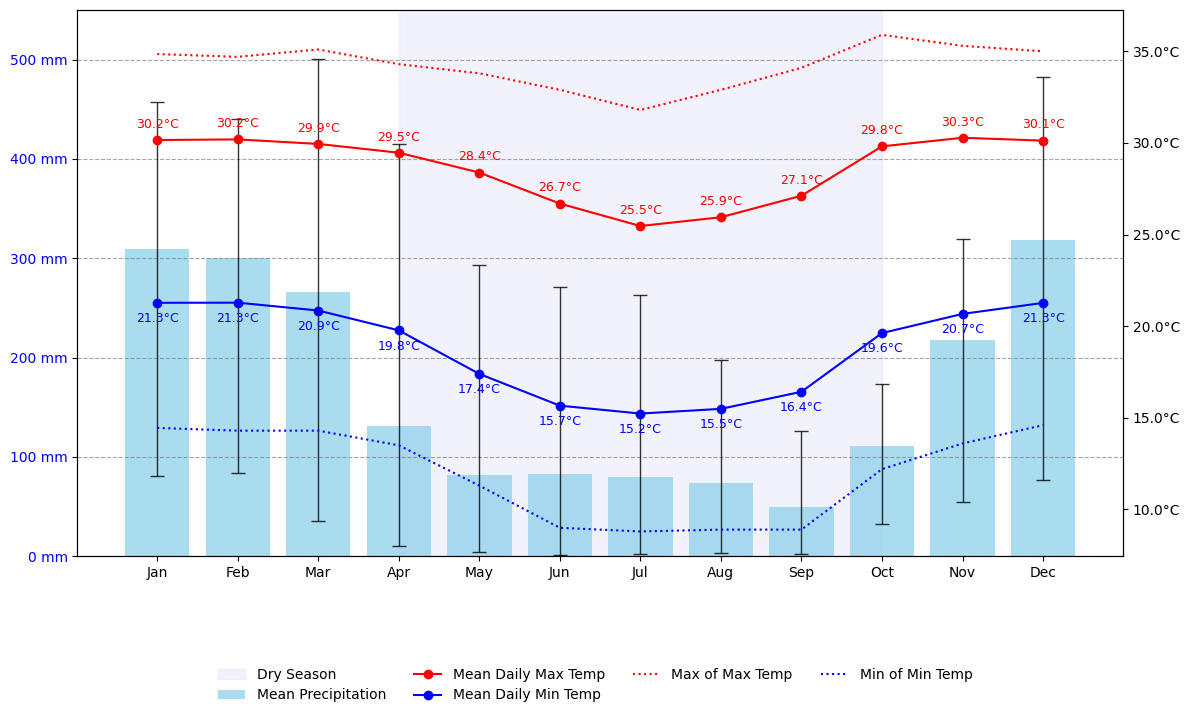

In [25]:
plot_climate_statistics(df)

In [24]:
df.head()

df.to_csv(r"..\..\data\coll_caff_node_new_jan.csv")

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def plot_climate_statistics(df):
    """
    Plots monthly climate statistics including temperature and precipitation.

    Parameters:
        df (pd.DataFrame): DataFrame containing monthly climate data with 36 columns.
                           - First 12 columns: Min Temperatures
                           - Next 12 columns: Max Temperatures
                           - Last 12 columns: Precipitation

    Returns:
        None
    """

    # Extract the first 36 columns
    df_extracted = df.iloc[:, :36]

    # Split into temperature and precipitation data
    min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
    max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
    precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation

    # Compute statistics
    mean_min_temps = min_temps.mean() / 10
    mean_max_temps = max_temps.mean() / 10
    min_monthly_min_temps = min_temps.min() / 10
    max_monthly_max_temps = max_temps.max() / 10
    mean_precip = precip.mean()
    min_precip = precip.min()
    max_precip = precip.max()

    # Define months for x-axis
    months = [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ]

    # Formatter functions
    def mm_formatter(x, pos):
        return f"{x:.0f} mm"

    def c_formatter(x, pos):
        return f"{x:.1f}°C"

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Highlight dry season
    ax1.axvspan(3, 9, color="lavender", alpha=0.5, label="Dry Season")
    ax1.grid(axis="y", linestyle="--", alpha=0.7, color="gray")

    # Plot precipitation bars with ranges
    lower_deviation = mean_precip - min_precip
    upper_deviation = max_precip - mean_precip
    ax1.bar(
        months,
        mean_precip,
        yerr=[lower_deviation, upper_deviation],
        color="skyblue",
        alpha=0.7,
        label="Mean Precipitation",
        capsize=5,
        error_kw={"elinewidth": 1, "alpha": 0.8},
    )
    ax1.set_ylim(0, 550)
    ax1.yaxis.set_major_formatter(FuncFormatter(mm_formatter))
    ax1.tick_params(axis="y", labelcolor="blue")

    # Create twin axis for temperature
    ax2 = ax1.twinx()

    # Plot mean daily temperatures
    ax2.plot(
        months,
        mean_max_temps,
        color="red",
        linestyle="-",
        marker="o",
        label="Mean Daily Max Temp",
    )
    ax2.plot(
        months,
        mean_min_temps,
        color="blue",
        linestyle="-",
        marker="o",
        label="Mean Daily Min Temp",
    )

    # Plot min of min temps and max of max temps (dotted lines)
    ax2.plot(
        months,
        max_monthly_max_temps,
        color="red",
        linestyle="dotted",
        label="Max of Max Temp",
    )
    ax2.plot(
        months,
        min_monthly_min_temps,
        color="blue",
        linestyle="dotted",
        label="Min of Min Temp",
    )

    # Annotate temperature lines with values
    for i, (min_temp, max_temp) in enumerate(zip(mean_min_temps, mean_max_temps)):
        ax2.text(
            i,
            max_temp + 0.5,
            f"{max_temp:.1f}°C",
            color="red",
            ha="center",
            va="bottom",
            fontsize=9,
        )
        ax2.text(
            i,
            min_temp - 0.5,
            f"{min_temp:.1f}°C",
            color="blue",
            ha="center",
            va="top",
            fontsize=9,
        )

    ax2.yaxis.set_major_formatter(FuncFormatter(c_formatter))
    ax2.tick_params(axis="y", labelcolor="black")

    # Add legends
    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=4,
        frameon=False,
        fontsize=10,
    )

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()